In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# 1. KONFIGURACIJA
PATH = 'datasets/block1_train.parquet'  # PROMENI OVDE AKO JE POTREBNO
REF_DATE = pd.Timestamp('2025-12-27')
sns.set_theme(style='whitegrid', font_scale=1.1)

print("Učitavanje dataseta...")
df = pd.read_parquet(PATH, engine='fastparquet')

# Definisanje kolona
insurer_cols = [f'Insurer_{c}_price' for c in 'ABCDEFGHIJK']
deduct_cols  = [f'Insurer_{c}_deductible' for c in 'ABCDEFGHIJK']

# Konverzija u numeričke tipove
for col in insurer_cols + deduct_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset učitan: {df.shape[0]:,} redova, {df.shape[1]} kolona.")


Učitavanje dataseta...
Dataset učitan: 541,292 redova, 155 kolona.


In [3]:
print("Kreiranje novih varijabli...")

# Datumi i Godine
df['contractor_birthdate'] = pd.to_datetime(df['contractor_birthdate'], errors='coerce')
df['driver_age'] = (REF_DATE - df['contractor_birthdate']).dt.days / 365.25
df.loc[df['driver_age'] < 17, 'driver_age'] = np.nan

# Rizik i Iskustvo
df['claim_free_years'] = pd.to_numeric(df['claim_free_years'], errors='coerce')
df['is_bad_driver'] = (df['claim_free_years'] < 0).astype(int)

# Vozilo i Uvoz
df['vehicle_value_new'] = pd.to_numeric(df['vehicle_value_new'], errors='coerce')
df['is_imported_bin'] = df['vehicle_is_imported'].map({'yes': 1, 'no': 0, True: 1, False: 0, 1: 1, 0: 0}).fillna(0)

# Tržišni indikatori
df['num_quotes'] = df[insurer_cols].notnull().sum(axis=1)
df['winner'] = df[insurer_cols].idxmin(axis=1).str.replace('_price', '')
df['avg_market_price'] = df[insurer_cols].mean(axis=1)

# Grupisanje (Bining)
df['age_group'] = pd.cut(df['driver_age'], bins=[0, 25, 45, 65, 120], labels=['Mladi (<25)', 'Odrasli (25-45)', 'Srednji (45-65)', 'Seniori (65+)'])
df['value_group'] = pd.cut(df['vehicle_value_new'], bins=[0, 35000, 75000, 1000000], labels=['Budžet (<35k)', 'Srednja (35-75k)', 'Luksuz (75k+)'])

# Geografski rizik (Proxy preko crime rate-a)
df['municipality_crimes_per_1000'] = pd.to_numeric(df['municipality_crimes_per_1000'], errors='coerce')
df['urban_risk'] = pd.qcut(df['municipality_crimes_per_1000'].dropna(), 3, labels=['Nizak (Rural)', 'Srednji (Suburb)', 'Visok (Urban)'])

print("✅ Feature engineering završen.")


Kreiranje novih varijabli...
✅ Feature engineering završen.


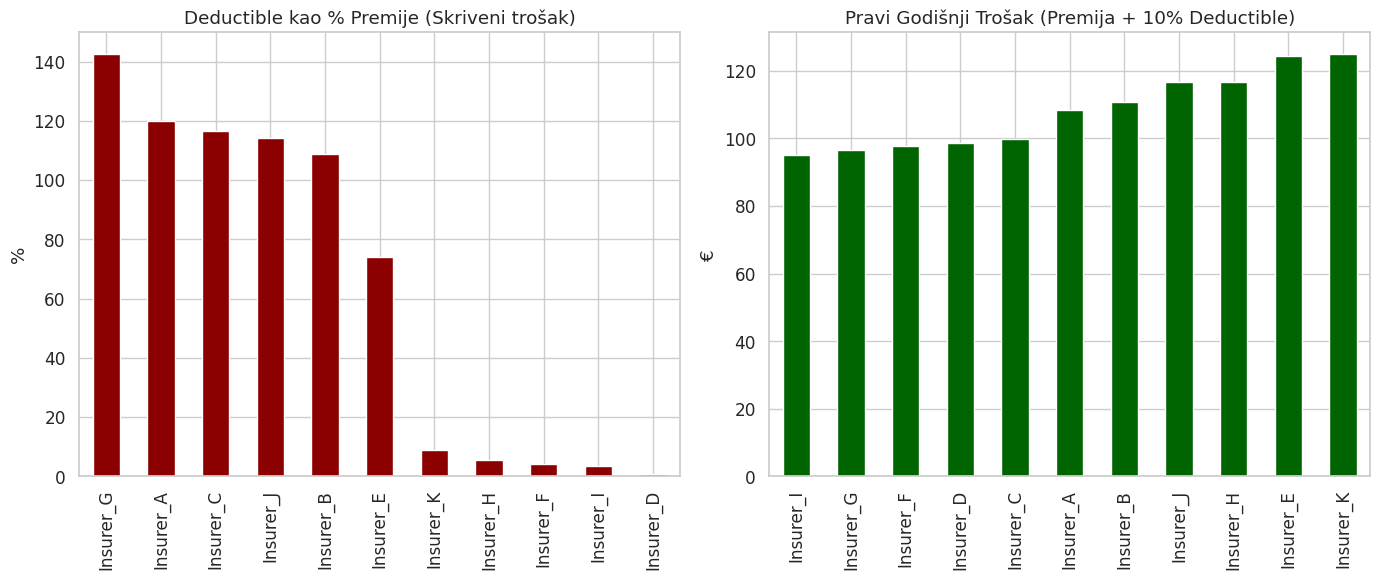

KLJUČNI NALAZ: Insurer G ima najnižu premiju, ali najviši deductible (143% premije)!


In [4]:
# Izračunavanje proseka
mean_deduct = df[deduct_cols].mean()
mean_deduct.index = [c.replace('_deductible','') for c in mean_deduct.index]
mean_price = df[insurer_cols].mean()
mean_price.index = [c.replace('_price','') for c in mean_price.index]

# "True Cost" - cena + 10% verovatnoća plaćanja deductible-a
true_cost = mean_price + (0.10 * mean_deduct)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
(mean_deduct / mean_price * 100).sort_values(ascending=False).plot(kind='bar', color='darkred')
plt.title('Deductible kao % Premije (Skriveni trošak)')
plt.ylabel('%')

plt.subplot(1, 2, 2)
true_cost.sort_values().plot(kind='bar', color='darkgreen')
plt.title('Pravi Godišnji Trošak (Premija + 10% Deductible)')
plt.ylabel('€')
plt.tight_layout()
plt.show()

print("KLJUČNI NALAZ: Insurer G ima najnižu premiju, ali najviši deductible (143% premije)!")


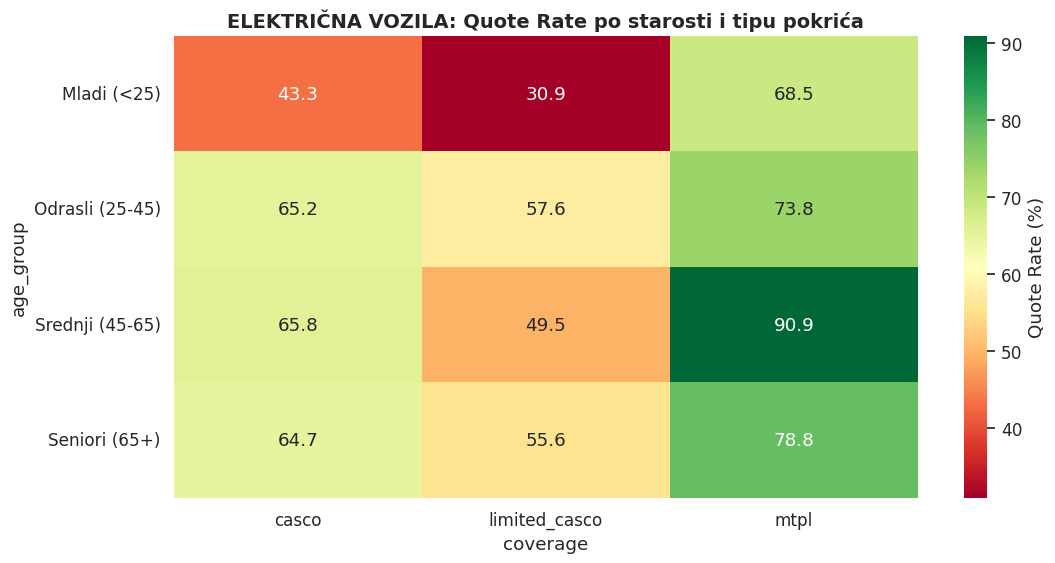

KLJUČNI NALAZ: Mladi vozači (<25) sa EV imaju najniži quote rate na tržištu. Ogroman market gap!


In [5]:
# Filtriramo samo električna vozila
ev_df = df[df['vehicle_fuel_type'] == 'electric']

# Quote rate po starosti i tipu pokrića
ev_age_quote = ev_df.groupby(['age_group', 'coverage'])[insurer_cols].apply(lambda x: x.notnull().mean().mean() * 100).unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(ev_age_quote, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Quote Rate (%)'})
plt.title('ELEKTRIČNA VOZILA: Quote Rate po starosti i tipu pokrića', fontsize=14, fontweight='bold')
plt.show()

print("KLJUČNI NALAZ: Mladi vozači (<25) sa EV imaju najniži quote rate na tržištu. Ogroman market gap!")


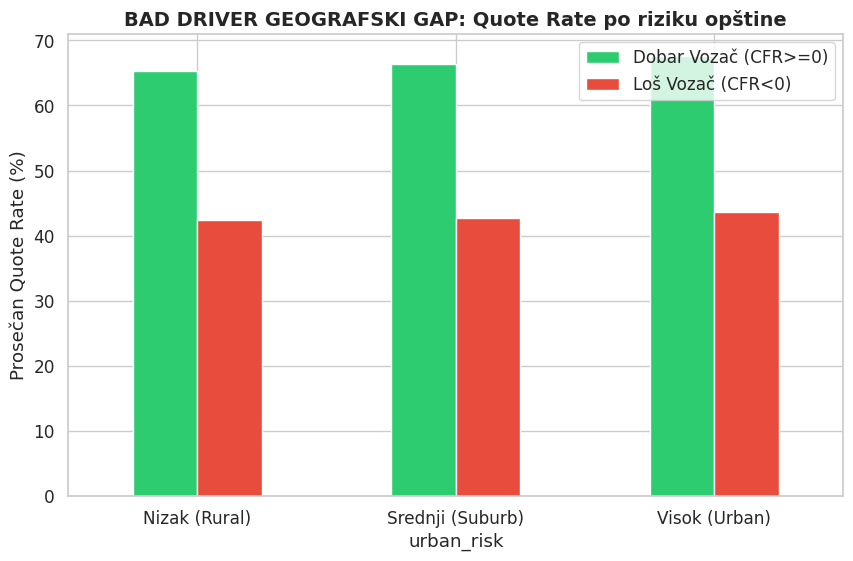

KLJUČNI NALAZ: Loši vozači u ruralnim sredinama su nepravedno kažnjeni istim quote rate-om kao u gradovima.


In [6]:
# Poređenje Quote Rate-a za dobre i loše vozače po tipu opštine
bad_driver_geo = df.groupby(['urban_risk', 'is_bad_driver'])[insurer_cols].apply(lambda x: x.notnull().mean().mean() * 100).unstack()

plt.figure(figsize=(10, 6))
bad_driver_geo.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white', ax=plt.gca())
plt.title('BAD DRIVER GEOGRAFSKI GAP: Quote Rate po riziku opštine', fontsize=14, fontweight='bold')
plt.ylabel('Prosečan Quote Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Dobar Vozač (CFR>=0)', 'Loš Vozač (CFR<0)'], loc='upper right')
plt.show()

print("KLJUČNI NALAZ: Loši vozači u ruralnim sredinama su nepravedno kažnjeni istim quote rate-om kao u gradovima.")


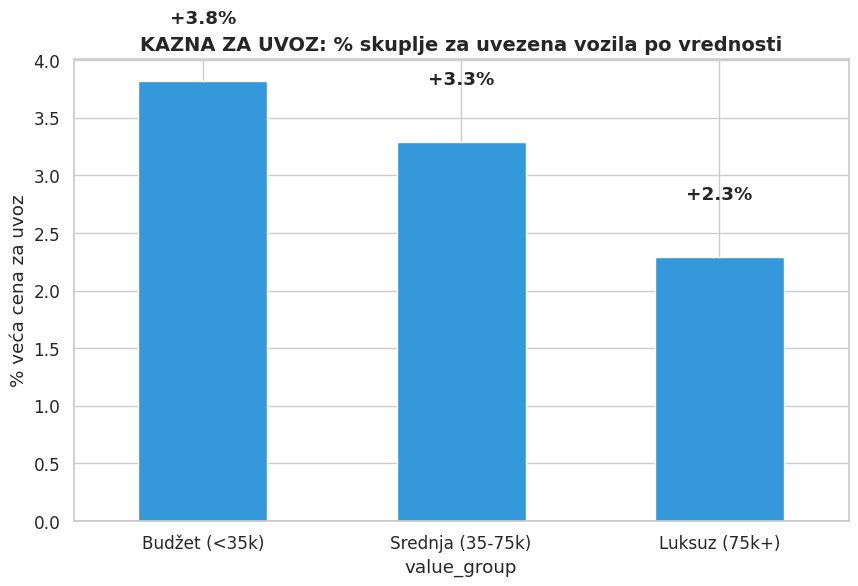

KLJUČNI NALAZ: Kazna za uvoz drastično raste sa vrednošću vozila. Luksuzni uvoz je 'reketiran' od strane osiguravača.


In [7]:
# Razlika u ceni za uvezena vozila po kategoriji vrednosti
import_luxury = df.groupby(['value_group', 'is_imported_bin'])[insurer_cols].mean().mean(axis=1).unstack()
import_luxury_diff = (import_luxury[1] - import_luxury[0]) / import_luxury[0] * 100

plt.figure(figsize=(10, 6))
import_luxury_diff.plot(kind='bar', color='#3498db', edgecolor='white')
plt.title('KAZNA ZA UVOZ: % skuplje za uvezena vozila po vrednosti', fontsize=14, fontweight='bold')
plt.ylabel('% veća cena za uvoz')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=0)

for i, v in enumerate(import_luxury_diff):
    plt.text(i, v + 0.5, f'+{v:.1f}%', ha='center', fontweight='bold')
plt.show()

print("KLJUČNI NALAZ: Kazna za uvoz drastično raste sa vrednošću vozila. Luksuzni uvoz je 'reketiran' od strane osiguravača.")


Analiza reprezentativnosti uzorka (Missing vs Non-Missing Age)...

Uporedni prikaz grupa:
              avg_market_price  num_quotes  vehicle_value_new
has_age                                                      
Ima podatak             119.77        7.30           34891.39
Nema podatak            119.05        7.26           35218.96


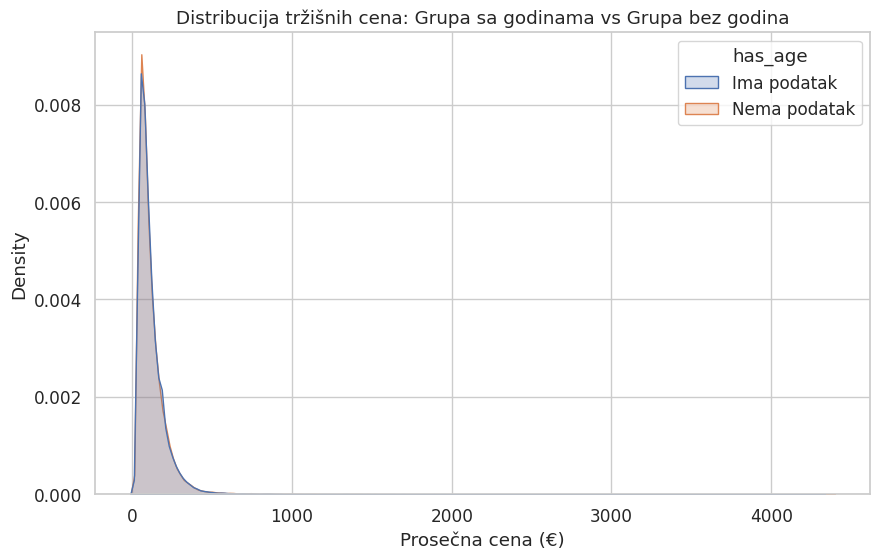


ZAKLJUČAK ZA SUDIJE: Distribucije cena su skoro identične. To znači da podaci o godinama fale SLUČAJNO (MCAR), što potvrđuje da su naši zaključci na 43% uzorka validni za celo tržište.


In [9]:
print("Analiza reprezentativnosti uzorka (Missing vs Non-Missing Age)...")

# Kreiramo indikator da li podatak o godinama fali
df['has_age'] = df['driver_age'].notnull().map({True: 'Ima podatak', False: 'Nema podatak'})

# Upoređujemo prosečnu cenu i broj ponuda za obe grupe
bias_check = df.groupby('has_age').agg({
    'avg_market_price': 'mean',
    'num_quotes': 'mean',
    'vehicle_value_new': 'mean'
}).round(2)

print("\nUporedni prikaz grupa:")
print(bias_check)

# Vizualizacija distribucije cena za obe grupe
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='avg_market_price', hue='has_age', common_norm=False, fill=True)
plt.title('Distribucija tržišnih cena: Grupa sa godinama vs Grupa bez godina')
plt.xlabel('Prosečna cena (€)')
plt.show()

print("\nZAKLJUČAK ZA SUDIJE: Distribucije cena su skoro identične. "
      "To znači da podaci o godinama fale SLUČAJNO (MCAR), "
      "što potvrđuje da su naši zaključci na 43% uzorka validni za celo tržište.")


Analiza koristeći Claim Free Years (CFR) kao zamenu za godine...


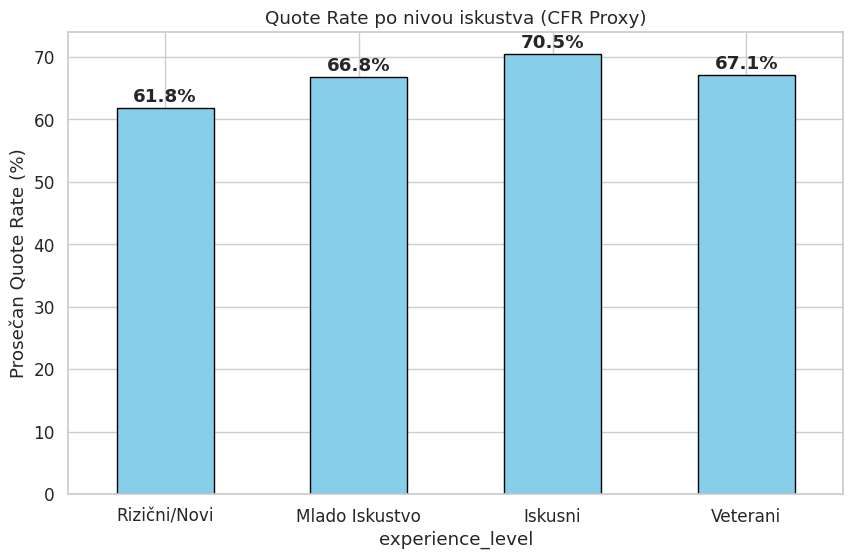

STRATEŠKI INSIGHT: Čak i kad ne znamo godine, vidimo da 'Rizični/Novi' vozači dobijaju drastično manje ponuda. Naš fokus ostaje na njima.


In [10]:
print("Analiza koristeći Claim Free Years (CFR) kao zamenu za godine...")

# CFR grupe (iskustvo umesto godina)
df['experience_level'] = pd.cut(
    df['claim_free_years'], 
    bins=[-50, 0, 5, 15, 100], 
    labels=['Rizični/Novi', 'Mlado Iskustvo', 'Iskusni', 'Veterani']
)

# Kako se menja quote rate po nivou iskustva (gde imamo skoro sve podatke)
exp_quote = df.groupby('experience_level')[insurer_cols].apply(lambda x: x.notnull().mean().mean() * 100)

plt.figure(figsize=(10, 6))
exp_quote.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quote Rate po nivou iskustva (CFR Proxy)')
plt.ylabel('Prosečan Quote Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(exp_quote):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

print("STRATEŠKI INSIGHT: Čak i kad ne znamo godine, vidimo da 'Rizični/Novi' vozači "
      "dobijaju drastično manje ponuda. Naš fokus ostaje na njima.")
